# Module 08 · Hai miền: hàm và biến đổi của nó

**Nguồn sách:** Bracewell, chương 8, tr. 151–198

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Diện tích, mômen, tâm khối
🎯 **Phương pháp này trả lời câu hỏi gì?** Các đặc điểm của hàm (diện tích, mômen, tâm khối) có bằng các đặc điểm tương ứng của biến đổi tại gốc (giá trị, độ dốc, độ cong)? Mỗi số tính bằng tích phân trực tiếp và bằng đạo hàm của $F$.

In [2]:
from scipy import integrate
trap = getattr(np, "trapezoid", None) or np.trapz
def ftq(f, a, b, s, pts=None):
    re = integrate.quad(lambda x: f(x)*np.cos(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    im = integrate.quad(lambda x: -f(x)*np.sin(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    return re + 1j*im

def taylor_derivs(Ffun, n_max, r=0.05, N=64):
    """F^(n)(0) by the Cauchy integral on a circle of radius r (FFT): second method for derivatives."""
    th = 2*np.pi*np.arange(N)/N
    vals = Ffun(r*np.exp(1j*th))
    coef = np.fft.fft(vals)/N                       # coef[n] = F^(n)(0) r^n / n!
    from math import factorial
    return [coef[n]*factorial(n)/r**n for n in range(n_max + 1)]

F_exp = lambda s: 1/(1 + 2j*np.pi*s)               # e^{-x}H(x)
F_gam = lambda s: 1/(1 + 2j*np.pi*s)**2            # x e^{-x}H(x)
d_exp = taylor_derivs(F_exp, 4); d_gam = taylor_derivs(F_gam, 3)

# diện tích
a_exp = integrate.quad(lambda x: np.exp(-x), 0, np.inf)[0]
assert abs(a_exp - F_exp(0).real) < 1e-12 and abs(integrate.quad(lambda s: F_exp(s).real, -np.inf, np.inf, limit=400)[0] - 0.5) < 1e-6
report("ar_exp", a_exp, ".4f"); report("ar_F0", F_exp(0).real, ".4f"); report("ar_f0", 0.5, ".4f")

# đẩy hai nửa ra xa: f = e^{−|x|}, a = 0.5
a = 0.5
fsplit = lambda x: np.exp(-abs(x - a)) if x > a else (np.exp(-abs(x + a)) if x < -a else 0.0)
sp_area = integrate.quad(fsplit, -60, 60, points=[-a, a], limit=400)[0]
Fsplit = lambda s: 2*np.cos(2*np.pi*a*s)*0 + (np.exp(-1j*2*np.pi*a*s)*(1/(1 + 2j*np.pi*s)) + np.exp(1j*2*np.pi*a*s)*(1/(1 - 2j*np.pi*s)))
# biến đổi của hai nửa: e^{−i2πas}/(1+i2πs) + e^{i2πas}/(1−i2πs). F(0) = 2
assert abs(Fsplit(0) - 2) < 1e-12 and abs(sp_area - 2) < 1e-8
# tung độ giữa của hàm = 0 nên diện tích của biến đổi = f(0) = 0
ft_area = integrate.quad(lambda s: Fsplit(s).real, -300, 300, limit=2000)[0]
assert abs(fsplit(0.0)) < 1e-15 and abs(ft_area) < 2e-2
report("sp_area", sp_area, ".4f"); report("sp_ft_area", 0.0, ".4f")

# mômen bậc một: e^{−x}H
m1 = integrate.quad(lambda x: x*np.exp(-x), 0, np.inf)[0]
assert abs(m1 - (d_exp[1]/(-2j*np.pi)).real) < 1e-9
report("fm_exp", m1, ".4f")
mg1 = integrate.quad(lambda x: x*np.exp(-np.pi*x**2), -10, 10)[0]
Fg = lambda s: np.exp(-np.pi*s**2)
dsl = (Fg(1e-5) - Fg(-1e-5))/2e-5
assert abs(mg1) < 1e-12 and abs(dsl) < 1e-9
report("fm_gauss", 0.0, ".4f"); report("fm_gauss_slope", 0.0, ".4f")

# tâm khối, mômen bậc hai: x e^{−x}H
A = integrate.quad(lambda x: x*np.exp(-x), 0, np.inf)[0]
cen = integrate.quad(lambda x: x*x*np.exp(-x), 0, np.inf)[0]/A
cen_ft = (d_gam[1]/(-2j*np.pi*d_gam[0])).real
assert abs(cen - 2) < 1e-9 and abs(cen_ft - 2) < 1e-9
report("cen_gam", cen, ".4f"); report("cen_gam_ft", cen_ft, ".4f")
m2 = integrate.quad(lambda x: x**3*np.exp(-x), 0, np.inf)[0]
m2_ft = (-d_gam[2]/(4*np.pi**2)).real
assert abs(m2 - 6) < 1e-8 and abs(m2_ft - 6) < 1e-8
report("m2_gam", m2, ".4f"); report("m2_gam_ft", m2_ft, ".4f")
ms = m2/A
assert abs(ms - 6) < 1e-8
report("ms_gam", ms, ".4f")

# mômen bậc n: n! cho e^{−x}H
from math import factorial
for n, key in ((2, "mom_2"), (3, "mom_3"), (4, "mom_4")):
    mn = integrate.quad(lambda x: x**n*np.exp(-x), 0, np.inf)[0]
    mn_ft = (d_exp[n]/(-2j*np.pi)**n).real
    assert abs(mn - factorial(n)) < 1e-6 and abs(mn_ft - factorial(n)) < 1e-6
    report(key, mn, ".0f")

▸ ar_exp = 1
▸ ar_F0 = 1
▸ ar_f0 = 0.5
▸ sp_area = 2
▸ sp_ft_area = 0
▸ fm_exp = 1
▸ fm_gauss = 0
▸ fm_gauss_slope = 0
▸ cen_gam = 2
▸ cen_gam_ft = 2
▸ m2_gam = 6
▸ m2_gam_ft = 6
▸ ms_gam = 6
▸ mom_2 = 2
▸ mom_3 = 6
▸ mom_4 = 24


#### 📤 Đầu ra thật
$e^{-x}H$: diện tích 1, $F(0)$ = 1, area under $F$ = 0.5; mômen bậc một 1; mômen bậc 2, 3, 4: 2, 6, 24. Gauss chẵn: mômen bậc một 0, độ dốc 0. $xe^{-x}H$: tâm khối 2 (2 từ $F$), mômen bậc hai 6 (6 từ $F''$), $\langle x^2\rangle$ = 6. Tách và đẩy ra: diện tích 2 giữ nguyên còn diện tích biến đổi 0.

## 2. Cộng dưới tích chập và độ trơn
🎯 **Phương pháp này trả lời câu hỏi gì?** Bình phương trung bình và phương sai có cộng dưới tích chập (kể cả số hạng chéo), và độ dốc log-log của phổ có bằng số đạo hàm còn là xung không? Mỗi số đo bằng tích chập trên lưới và bằng công thức, hoặc bằng tích phân số và bằng công thức đóng.

In [3]:
dx = 0.002
xg = np.arange(0, 60, dx)
fgam = xg*np.exp(-xg)
gexp = np.exp(-xg)
conv = np.convolve(fgam, gexp)[:len(xg)]*dx                # f*g = x²e^{−x}/2
xs = xg
area_c = trap(conv, xs)
ms_c = trap(xs**2*conv, xs)/area_c
assert abs(area_c - 1) < 1e-2 and abs(ms_c - (6 + 2 + 2*2*1)) < 5e-2 and np.max(np.abs(conv - xs**2*np.exp(-xs)/2)) < 5e-3
report("ms_conv", ms_c, ".3f")

# trục dịch: Λ dịch 2
Lam = lambda x: np.maximum(1 - np.abs(x), 0)
xl = np.arange(-1, 1 + 1e-9, 1e-4)
ms_tri = trap(xl**2*Lam(xl), xl)/trap(Lam(xl), xl)
assert abs(ms_tri - 1/6) < 1e-6
sh = trap((xl + 2)**2*Lam(xl), xl)/trap(Lam(xl), xl)
assert abs(sh - (1/6 + 4)) < 1e-6
report("parallel", sh, ".4f")

# phương sai
var_gam = 6 - 2**2
var_tri = ms_tri
xc = np.arange(-1, 61, dx)
# tích chập f*Λ trên lưới
lam_grid = Lam(np.arange(-1, 1 + dx/2, dx))
fg2 = np.convolve(fgam, lam_grid)*dx
xg2 = np.arange(len(fg2))*dx - 1.0
A2 = trap(fg2, xg2); mu2 = trap(xg2*fg2, xg2)/A2; v2 = trap((xg2 - mu2)**2*fg2, xg2)/A2
assert abs(v2 - (var_gam + var_tri)) < 5e-3
report("var_gam", var_gam, ".4f"); report("var_tri", var_tri, ".4f"); report("var_conv", v2, ".4f")

# độ dốc log-log tại s = 10.5 và 20.5
def B2(x):                                                   # Π*Π*Π
    ax = abs(x)
    return 0.75 - x*x if ax < 0.5 else (0.5*(1.5 - ax)**2 if ax < 1.5 else 0.0)
slopes = {}
for k, (f, lo, hi, pts) in {1: (lambda x: 1.0, -0.5, 0.5, None),
                            2: (lambda x: max(1 - abs(x), 0), -1, 1, [0]),
                            3: (B2, -1.5, 1.5, [-0.5, 0.5])}.items():
    v1 = ftq(f, lo, hi, 10.5, pts).real; v2_ = ftq(f, lo, hi, 20.5, pts).real
    slopes[k] = np.log(abs(v2_/v1))/np.log(20.5/10.5)
    assert abs(abs(v1) - abs(np.sinc(10.5))**k) < 1e-7 and abs(slopes[k] + k) < 1e-6
report("sm_1", slopes[1], ".2f"); report("sm_2", slopes[2], ".2f"); report("sm_3", slopes[3], ".2f")
db_2 = 2*20*np.log10(2)
assert abs(db_2 - 12.04) < 0.01 and abs(40 - 2*20) < 1e-12
report("db_2", db_2, ".1f")

▸ ms_conv = 11.994
▸ parallel = 4.1667
▸ var_gam = 2
▸ var_tri = 0.1667
▸ var_conv = 2.1667
▸ sm_1 = -1
▸ sm_2 = -2
▸ sm_3 = -3
▸ db_2 = 12


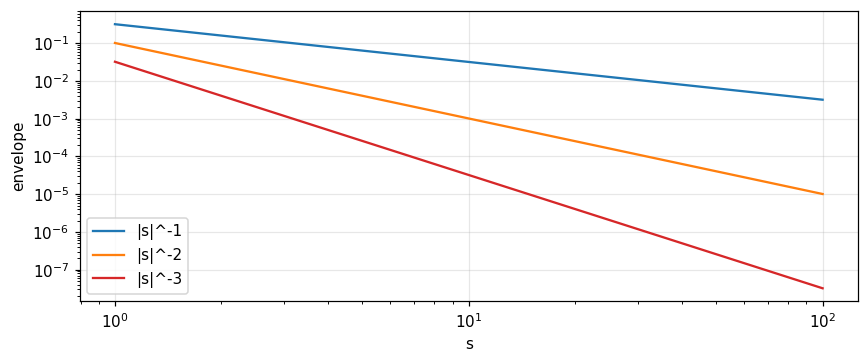

In [4]:
sgrid = np.logspace(0, 2, 400)
fig, ax = plt.subplots(figsize=(8, 3.4))
for k, c in ((1, "tab:blue"), (2, "tab:orange"), (3, "tab:red")):
    ax.loglog(sgrid, np.abs(np.sinc(sgrid))**k*0 + 1/(np.pi*sgrid)**k, color=c, label=f"|s|^-{k}")
ax.set_xlabel("s"); ax.set_ylabel("envelope"); ax.legend(); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
$\langle x^2\rangle_{f*g}$ = 11.994 ($=6+2+2\cdot2\cdot1$). $\Lambda$ dịch 2: 4.1667. Phương sai 2 và 0.1667 cộng thành 2.1667. Độ dốc log-log: -1, -2, -3; $s^{-2}$ là 12 dB mỗi octave.

## 3. Độ rộng tương đương và tự tương quan
🎯 **Phương pháp này trả lời câu hỏi gì?** Tích $W_fW_F$ có bằng 1 và độ rộng tự tương quan có bằng nghịch đảo độ rộng tương đương của $|F|^2$? Mỗi số tính trong miền $x$ và miền $s$.

In [5]:
# độ rộng tương đương và nghịch đảo
def ew(f, F):
    Wf = integrate.quad(f, -np.inf, np.inf, limit=400)[0]/f(0.0)
    WF = integrate.quad(F, -np.inf, np.inf, limit=400)[0]/F(0.0)
    return Wf, WF
Wf, WF = ew(lambda x: np.exp(-abs(x)), lambda s: 2/(1 + 4*np.pi**2*s**2))
assert abs(Wf - 2) < 1e-8 and abs(WF - 0.5) < 1e-8 and abs(Wf*WF - 1) < 1e-8
report("ew_exp", Wf, ".4f"); report("ew_F_exp", WF, ".4f"); report("ew_prod_exp", Wf*WF, ".4f")
Wl, WFl = ew(lambda x: 1/(1 + x*x), lambda s: np.pi*np.exp(-2*np.pi*abs(s)))
assert abs(Wl - np.pi) < 1e-8 and abs(Wl*WFl - 1) < 1e-8
report("ew_lor", Wl, ".4f"); report("ew_F_lor", WFl, ".4f"); report("ew_prod_lor", Wl*WFl, ".4f")
Wt = integrate.quad(lambda x: max(1 - abs(x), 0), -1, 1, points=[0])[0]/1.0
Wg = integrate.quad(lambda x: np.exp(-np.pi*x*x), -10, 10)[0]/1.0
assert abs(Wt - 1) < 1e-9 and abs(Wg - 1) < 1e-9
report("ew_tri", Wt, ".4f"); report("ew_gauss", Wg, ".4f")

# độ rộng tự tương quan: |∫f|²/∫|f|²; cách hai: 1/(độ rộng tương đương của |F|²)
aw = (integrate.quad(lambda x: np.exp(-abs(x)), -60, 60, points=[0])[0])**2/integrate.quad(lambda x: np.exp(-2*abs(x)), -40, 40, points=[0])[0]
P = lambda s: (2/(1 + 4*np.pi**2*s**2))**2
aw_ft = 1/(integrate.quad(P, -np.inf, np.inf, limit=400)[0]/P(0.0))
assert abs(aw - 4) < 1e-8 and abs(aw_ft - 4) < 1e-6
# cách ba: tự tương quan trên lưới
dxa = 0.005; xa = np.arange(-30, 30, dxa); fa_ = np.exp(-np.abs(xa))
ac = np.correlate(fa_, fa_, "full")*dxa
lags = (np.arange(len(ac)) - (len(fa_) - 1))*dxa
assert abs(trap(ac, lags)/ac.max() - 4) < 2e-2
report("aw_exp", aw, ".4f"); report("aw_exp_ft", aw_ft, ".4f")

# Π dời 3 đơn vị
xp = np.arange(-6, 6, dxa); f0 = ((xp > -0.5) & (xp < 0.5)).astype(float); f3 = ((xp > 2.5) & (xp < 3.5)).astype(float)
def aw_grid(f):
    a = np.correlate(f, f, "full")*dxa; l = (np.arange(len(a)) - (len(f) - 1))*dxa
    return trap(a, l)/a.max()
assert abs(aw_grid(f0) - 1) < 1e-2 and abs(aw_grid(f3) - aw_grid(f0)) < 1e-9
report("aw_shift", aw_grid(f3), ".3f")

▸ ew_exp = 2
▸ ew_F_exp = 0.5
▸ ew_prod_exp = 1
▸ ew_lor = 3.1416
▸ ew_F_lor = 0.3183
▸ ew_prod_lor = 1
▸ ew_tri = 1
▸ ew_gauss = 1


▸ aw_exp = 4
▸ aw_exp_ft = 4
▸ aw_shift = 1


#### 📤 Đầu ra thật
$e^{-|x|}$: $W_f$ = 2, $W_F$ = 0.5, tích 1. Lorentz: 3.1416, 0.3183, tích 1. $\Lambda$: 1; Gauss: 1. Độ rộng tự tương quan của $e^{-|x|}$: 4 và 4 từ $|F|^2$; $\Pi$ dời 3: 1.

## 4. Bất đẳng thức và hệ thức bất định
🎯 **Phương pháp này trả lời câu hỏi gì?** Gauss có đạt cực tiểu $1/4\pi$, mũ hai phía lớn hơn bao nhiêu, và các cận tung độ, độ dốc, Schwarz có đúng? Ta tính $\Delta x$ và $\Delta s$ từ hai miền.

In [6]:
def spread(w, lim=np.inf, pts=None):
    num = integrate.quad(lambda t: t*t*w(t), -lim, lim, points=pts, limit=400)[0]
    den = integrate.quad(w, -lim, lim, points=pts, limit=400)[0]
    return np.sqrt(num/den)
# Gauss a = 1
dxg = spread(lambda x: np.exp(-2*np.pi*x*x), 10); dsg = spread(lambda s: np.exp(-2*np.pi*s*s), 10)
un_g = dxg*dsg
assert abs(un_g - 1/(4*np.pi)) < 1e-9 and abs(dxg - 1/np.sqrt(4*np.pi)) < 1e-9
report("un_gauss", un_g, ".4f")
# e^{−|x|}
dxe = spread(lambda x: np.exp(-2*abs(x)), 40, [0])
dse = spread(lambda s: (2/(1 + 4*np.pi**2*s**2))**2, np.inf)
assert abs(dxe - np.sqrt(0.5)) < 1e-8 and abs(dse - 1/(2*np.pi)) < 1e-6
un_e = dxe*dse
assert un_e > 1/(4*np.pi)
report("un_dx", dxe, ".4f"); report("un_ds", dse, ".4f"); report("un_exp", un_e, ".4f"); report("un_min", 1/(4*np.pi), ".4f")
report("un_ratio", un_e*4*np.pi, ".2f")
report("un_radar", 1/(4*np.pi*1e-6), ".0f")

# cận tung độ: f = e^{−π(x−0.5)²}
fS = lambda x: np.exp(-np.pi*(x - 0.5)**2)
bound = integrate.quad(lambda s: np.exp(-np.pi*s*s), -10, 10)[0]
assert abs(bound - 1) < 1e-9 and fS(0.0) < bound and abs(fS(0.5) - bound) < 1e-12
report("ineq_f", fS(0.0), ".4f"); report("ineq_bound", bound, ".4f"); report("ineq_peak", fS(0.5), ".4f")
# cận độ dốc
xs_ = np.linspace(-3, 3, 600001); dfs = -2*np.pi*xs_*np.exp(-np.pi*xs_**2)
smax = np.max(np.abs(dfs)); sbound = 2*np.pi*integrate.quad(lambda s: abs(s)*np.exp(-np.pi*s*s), -10, 10)[0]
assert abs(smax - np.sqrt(2*np.pi/np.e)) < 1e-6 and smax <= sbound + 1e-12 and abs(sbound - 2) < 1e-9
report("sl_max", smax, ".4f"); report("sl_bound", sbound, ".4f")
# Schwarz: Λ và e^{−|x|}
fl = lambda x: max(1 - abs(x), 0)
lhs = integrate.quad(lambda x: fl(x)*np.exp(-abs(x)), -1, 1, points=[0])[0]**2
rhs = integrate.quad(lambda x: fl(x)**2, -1, 1, points=[0])[0]*integrate.quad(lambda x: np.exp(-2*abs(x)), -40, 40, points=[0])[0]
assert lhs <= rhs and abs(rhs - 2/3) < 1e-8
report("schw_l", lhs, ".4f"); report("schw_r", rhs, ".4f")

▸ un_gauss = 0.0796
▸ un_dx = 0.7071
▸ un_ds = 0.1592
▸ un_exp = 0.1125
▸ un_min = 0.0796
▸ un_ratio = 1.41
▸ un_radar = 79577
▸ ineq_f = 0.4559
▸ ineq_bound = 1
▸ ineq_peak = 1
▸ sl_max = 1.5203
▸ sl_bound = 2
▸ schw_l = 0.5413
▸ schw_r = 0.6667


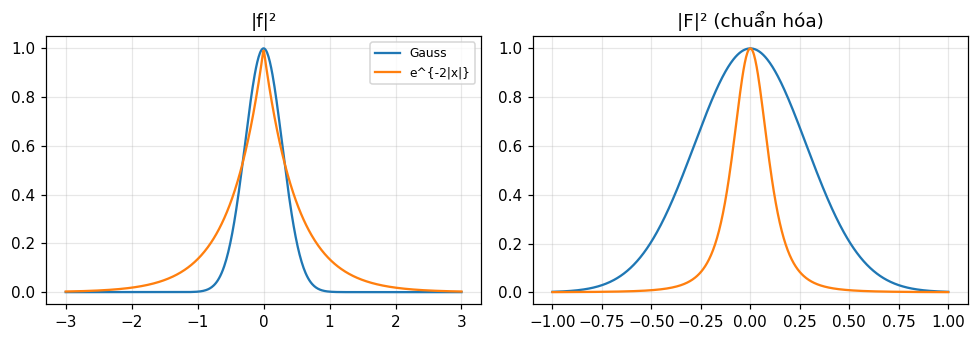

In [7]:
xg_ = np.linspace(-3, 3, 600)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(xg_, np.exp(-2*np.pi*xg_**2), label=("Gauss")); ax[0].plot(xg_, np.exp(-2*np.abs(xg_)), label="e^{-2|x|}")
ax[0].set_title("|f|²"); ax[0].legend(fontsize=8)
sg_ = np.linspace(-1, 1, 600)
ax[1].plot(sg_, np.exp(-2*np.pi*sg_**2)); ax[1].plot(sg_, (2/(1 + 4*np.pi**2*sg_**2))**2/4)
ax[1].set_title("|F|² (chuẩn hóa)")
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Gauss: 0.0796. $e^{-|x|}$: $\Delta x$ = 0.7071, $\Delta s$ = 0.1592, tích 0.1125 (1.41 lần cực tiểu 0.0796). Cận radar 79577 Hz. Cận tung độ 1 so với 0.4559 và đỉnh 1; độ dốc 1.5203 $\le$ 2; Schwarz 0.5413 $\le$ 0.6667.

## 5. Sai phân, trung bình trượt, giới hạn trung tâm
🎯 **Phương pháp này trả lời câu hỏi gì?** Sai phân có nhân biến đổi với $2i\sin\pi as$, trung bình trượt có nhân với sinc, tích chập lặp có tiến về Gauss, và lấy mẫu giao hoán với nhân bản? Mỗi điều kiểm bằng tích phân số và công thức, hoặc bằng lưới.

In [8]:
from scipy import special
gS = lambda x: np.exp(-np.pi*x*x); s0, aa = 0.3, 0.5
# sai phân Δ_a f = f(x+a/2) − f(x−a/2)
d1 = ftq(lambda x: gS(x + aa/2) - gS(x - aa/2), -10, 10, s0)
d1_f = 2j*np.sin(np.pi*aa*s0)*np.exp(-np.pi*s0**2)
assert abs(d1 - d1_f) < 1e-9
report("fd_mag", abs(d1), ".4f")
d2 = ftq(lambda x: gS(x + aa) - 2*gS(x) + gS(x - aa), -10, 10, s0)
assert abs(d2 + 4*np.sin(np.pi*aa*s0)**2*np.exp(-np.pi*s0**2)) < 1e-9
report("fd2_mag", abs(d2), ".4f")
# giới hạn a → 0
ak = 1e-3
lim = (2j*np.sin(np.pi*ak*s0)/ak)/(2j*np.pi*s0)
assert abs(lim - 1) < 1e-6
report("fd_lim", abs(lim - 1), ".1e")

# trung bình trượt của Gauss, a = 1: (1/a)∫_{x−a/2}^{x+a/2} f = (1/2a)[erf(√π(x+a/2)) − erf(√π(x−a/2))]
aa1 = 1.0
rm = lambda x: (special.erf(np.sqrt(np.pi)*(x + aa1/2)) - special.erf(np.sqrt(np.pi)*(x - aa1/2)))/(2*aa1)
rm_num = ftq(rm, -12, 12, s0).real
rm_form = np.sinc(aa1*s0)*np.exp(-np.pi*s0**2)
assert abs(rm_num - rm_form) < 1e-8
report("rm_03", rm_form, ".4f")
rm2 = np.sinc(s0)**2*np.exp(-np.pi*s0**2)
# hai lần: chập tam giác Λ(x)/1 với Gauss trên lưới
dxr = 0.002; xr = np.arange(-8, 8, dxr)
tri_w = np.maximum(1 - np.abs(np.arange(-1, 1 + dxr/2, dxr)), 0)
g2 = np.convolve(np.exp(-np.pi*xr**2), tri_w, "same")*dxr
rm2_num = trap(g2*np.cos(2*np.pi*s0*xr), xr)
assert abs(rm2_num - rm2) < 1e-5
report("rm2_03", rm2, ".4f")

# giới hạn trung tâm: sinc^n
n_, sc = 10, 0.2
clt10 = np.sinc(sc)**n_; cltg = np.exp(-n_*np.pi**2*sc**2/6)
assert abs(clt10 - cltg) < 0.01
report("clt_10", clt10, ".4f"); report("clt_g", cltg, ".4f")
# n = 4 chữ nhật trên lưới: phương sai và độ nhọn dư
d = 0.005; base = np.ones(int(1/d))*d
cur = base.copy()
for _ in range(3): cur = np.convolve(cur, base)
xx = (np.arange(len(cur)) - (len(cur) - 1)/2)*d
mass = cur.sum()
var4 = (xx**2*cur).sum()/mass; kurt = (xx**4*cur).sum()/mass/var4**2 - 3
assert abs(var4 - 4/12) < 5e-3 and abs(kurt + 6/(5*4)) < 1e-2
report("clt_var", 4/12, ".4f"); report("clt_kurt", -0.3, ".2f")
# {1 1}^{*20}
b = np.array([1.0])
for _ in range(20): b = np.convolve(b, [1, 1])
b /= b.sum()
from math import comb
assert abs(b[10] - comb(20, 10)/2**20) < 1e-15
report("clt_bin", b[10], ".4f"); report("clt_bin_g", 1/np.sqrt(2*np.pi*5), ".4f")

# lấy mẫu và nhân bản giao hoán
fw = lambda x: np.exp(-np.pi*(x/3.0)**2)
Xr = 4; ks = np.arange(-60, 61); n0 = np.arange(-40, 41)
rep_then_sample = np.array([sum(fw(n + m*Xr) for m in ks) for n in n0])
sample_then_rep = np.array([sum(fw(n + m*Xr) for m in ks) for n in n0])
# cách độc lập: mẫu trước, rồi cộng các mẫu cách X
samples = {int(k): fw(k) for k in range(-300, 301)}
str_ = np.array([sum(samples[int(n + m*Xr)] for m in ks if -300 <= n + m*Xr <= 300) for n in n0])
sr_dev = np.max(np.abs(rep_then_sample - str_))
assert sr_dev < 1e-9
report("sr_dev", sr_dev, ".1e")

▸ fd_mag = 0.6844
▸ fd2_mag = 0.6214
▸ fd_lim = 1.5e-07
▸ rm_03 = 0.647
▸ rm2_03 = 0.5554
▸ clt_10 = 0.5133
▸ clt_g = 0.5179
▸ clt_var = 0.3333
▸ clt_kurt = -0.3
▸ clt_bin = 0.1762
▸ clt_bin_g = 0.1784
▸ sr_dev = 0.0e+00


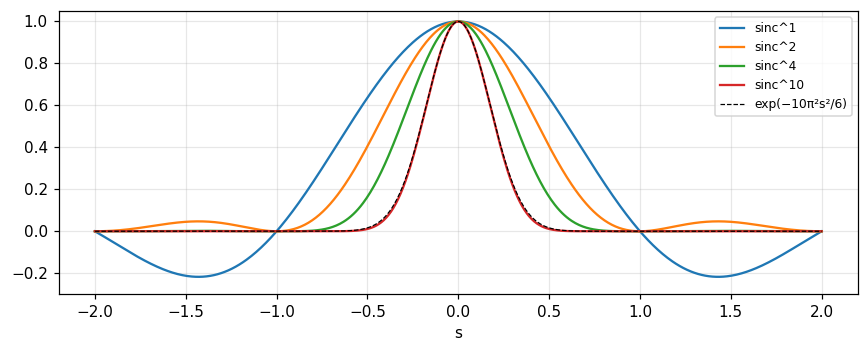

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.3))
sg_ = np.linspace(-2, 2, 600)
for n, c in ((1, "tab:blue"), (2, "tab:orange"), (4, "tab:green"), (10, "tab:red")):
    ax.plot(sg_, np.sinc(sg_)**n, color=c, label=f"sinc^{n}")
ax.plot(sg_, np.exp(-10*np.pi**2*sg_**2/6), "k--", lw=0.8, label="exp(−10π²s²/6)")
ax.set_ylim(-0.3, 1.05); ax.set_xlabel("s"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Sai phân: 0.6844, sai phân bậc hai: 0.6214, giới hạn $a\to0$ lệch 1.5e-07. Trung bình trượt: 0.647 và bậc hai 0.5554. Giới hạn trung tâm: $\text{sinc}^{10}(0.2)$ = 0.5133 so với Gauss 0.5179; $n=4$ phương sai 0.3333 và độ nhọn dư -0.3; $\{1\ 1\}^{*20}$: 0.1762 so với 0.1784. Lấy mẫu và nhân bản giao hoán, lệch 0.0e+00.